No pretrained configuration specified for ResNetSub model. Using a default. Please add a config to the model pretrained_cfg registry or pass explicitly.


-1.0 1.0


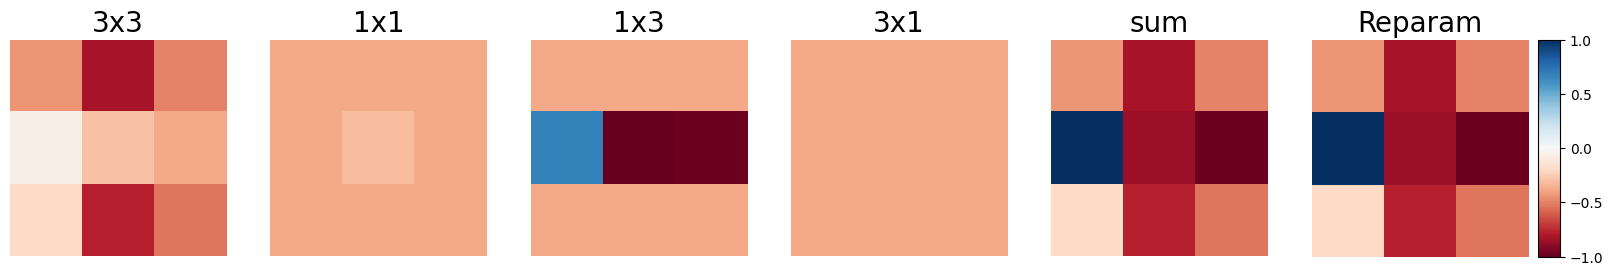

In [18]:
from functools import reduce
import os

import hydra
import matplotlib.pyplot as plt
import numpy
import torch
import torch.nn.functional as F
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

from src.models import *
from src.models.blocks import fuse_bn
from src.utils import clean_state_dict
from src.utils.factory import create_model_cls

methods = ['Add', 'Sub']
architecture = ['33', '333', 'InceptionV1', 'InceptionV2', 'InceptionV3', 'InceptionV2NoShuffle']
weight_name = 'model_best.pth.tar'
weight_root = 'weights'


def expend_kernel(kernel, target_kernel_size):
    H_pixels_to_pad = (target_kernel_size[0] - kernel.size(-2)) // 2
    W_pixels_to_pad = (target_kernel_size[1] - kernel.size(-1)) // 2
    return F.pad(kernel, [W_pixels_to_pad, W_pixels_to_pad, H_pixels_to_pad, H_pixels_to_pad])


def load_checkpoint(model, checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location='cpu')
    state_dict = clean_state_dict(checkpoint['state_dict'])
    model.load_state_dict(state_dict)


def inceptionv3_reparam(name, kernel):
    conv = kernel[0]
    bn = kernel[1]
    new_conv = torch.nn.Conv2d(conv.in_channels, conv.out_channels, conv.kernel_size, conv.stride, conv.padding,
                               conv.dilation, conv.groups, bias=True)

    if name == 'kxk':
        _k, _b = fuse_bn(conv, bn, 4)
    elif name == '1x1':
        _k, _b = fuse_bn(conv, bn, 4)
        _k = expend_kernel(_k, (3, 3))
    elif name == '1x3':
        _k, _b = fuse_bn(conv, bn, 4)
        _k = expend_kernel(_k, (3, 3))
    elif name == '3x1':
        _k, _b = fuse_bn(conv, bn, 4)
        _k = expend_kernel(_k, (3, 3))
    else:
        raise NameError

    new_conv.weight.data = _k
    new_conv.bias.data = _b
    return new_conv


def rsetattr(obj, attr, val):
    pre, _, post = attr.rpartition('.')
    return setattr(rgetattr(obj, pre) if pre else obj, post, val)


def rgetattr(obj, attr):
    return reduce(getattr, [obj] + attr.split('.'))


def deploy2(model):
    for name, module in model.named_modules():
        if hasattr(module, 're_parameterization'):
            module.re_parameterization()


def main():
    with hydra.initialize(config_path='configs', version_base='1.3'):
        cfg = hydra.compose(config_name='sub_imagenet')
        cfg.local_rank = 0

    connectivity = f'{methods[1]}{architecture[4]}'
    model_name = f'resnet50_{connectivity}'
    model = create_model_cls(
        model_name,
        in_channels=cfg.dataset.in_channels,
        num_classes=cfg.dataset.num_classes,
        stem_type=cfg.dataset.name,
    )
    load_checkpoint(model,
                    os.path.join(weight_root, cfg.dataset.name, model_name.split('_')[0], model_name + '.pth.tar'))

    kernels = list()
    names = list()

    for name, block in model.layer1[0].conv2.blocks.items():
        kernel = inceptionv3_reparam(name, block).weight[0].mean(0)
        kernels.append(kernel.detach().numpy())
        names.append(name)

    kernels = numpy.asarray(kernels)

    sum_kernel = kernels.sum(axis=0)

    kernels = kernels.tolist()
    kernels.append(sum_kernel.tolist())
    names.append("sum")

    # After re-param
    deploy2(model)
    kernel = model.layer1[0].conv2.conv_reparam.weight[0].mean(0)

    kernels.append(kernel.detach().numpy())
    names.append('Reparam')

    kernels = numpy.array(kernels)
    mini = kernels.min()
    maxi = kernels.max()
    kernels = 2 * (kernels - mini) / (maxi - mini) - 1

    fig = plt.figure(figsize=(20, 5))
    # cmap0 = LinearSegmentedColormap.from_list('mymy', ['#ffffff', '#000000'])
    spec = gridspec.GridSpec(nrows=1, ncols=6,
                             width_ratios=[1, 1, 1, 1, 1, 1.15])
    print(kernels.min(), kernels.max())
    for i in range(len(kernels)):
        ax = fig.add_subplot(spec[i])
        im = plt.imshow(kernels[i], cmap='RdBu', vmin=kernels.min(), vmax=kernels.max())
        ax.axis("off")
        ax.set_title(names[i] if names[i] != 'kxk' else '3x3', fontsize=20)

    divider = make_axes_locatable(plt.gca())
    cax = divider.append_axes("right", size="10%", pad=0.1)
    plt.colorbar(im, cax=cax)

    plt.savefig(f'assets/{model_name}_kmap.svg', dpi=500)
    plt.show()


main()